# Figure 4: Split-Half Diagnostics

Split-half stability diagnostic for PLS-SVD: split data into two halves, run PLS-SVD on each, measure consistency.

**Key insight:** Split-half uses N/2 samples per half, so aspect ratios are halved. This shifts the threshold from θ_crit to √2·θ_crit ≈ 1.414·θ_crit. The plot shows both thresholds to distinguish three regimes:
1. **No recovery** (θ < θ_crit): Signal too weak for any recovery
2. **Recovery unstable** (θ_crit < θ < √2·θ_crit): Full data recovers signal, but halves are unreliable
3. **Recovery stable** (θ > √2·θ_crit): Both full data and split-halves recover signal reliably

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm.notebook import tqdm

from src import _run_diagnostics_worker

# ICML-compatible styling
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

np.random.seed(42)

# Create directories
os.makedirs('../results', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

In [2]:
# Experiment parameters
N = 2000
alpha_x = 7.5
alpha_y = 7.5
Dx = int(N / alpha_x)
Dy = int(N / alpha_y)
mx = my = 0.1
rho = (1 - mx) * (1 - my)
theta_crit = 1 / ((alpha_x * alpha_y) ** 0.25 * np.sqrt(rho))
theta_values = np.linspace(0.5 * theta_crit, 2.5 * theta_crit, 60)
n_trials = 25

# Check for cached results or run experiment
os.makedirs('../results', exist_ok=True)
cache_file = '../results/fig4_results.pkl'

if os.path.exists(cache_file):
    print("Loading cached results...")
    with open(cache_file, 'rb') as f:
        results = pickle.load(f)
    print("Done!")
else:
    print(f"Running experiment for N={N}...")
    
    args_list = []
    for theta in theta_values:
        params_dict = {'N': N, 'Dx': Dx, 'Dy': Dy, 'theta': theta, 'mx': mx, 'my': my}
        args_list.append((params_dict, n_trials, theta, theta_crit))
    
    with Pool() as pool:
        results = list(tqdm(pool.imap(_run_diagnostics_worker, args_list),
                           total=len(args_list), desc="θ sweep"))
    
    with open(cache_file, 'wb') as f:
        pickle.dump(results, f)
    print("Results cached!")

Loading cached results...
Done!


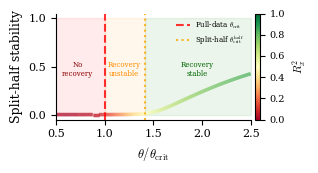


Figure saved: ../figures/fig4_split_half_diagnostics.pdf
Full-data threshold: θ/θ_crit = 1.0
Split-half threshold: θ/θ_crit = √2 ≈ 1.414


In [3]:
from matplotlib.collections import LineCollection
from scipy.interpolate import interp1d

# Create single-column figure (3.25" wide for ICML)
fig, ax = plt.subplots(figsize=(3.25, 1.8))

# Extract data
theta_norm = np.array([r['theta_norm'] for r in results])
stability = np.array([r['stability_x_mean'] for r in results])
rx2 = np.array([r['Rx2_mean'] for r in results])

# Interpolate to create smooth continuous line
n_interp = 500  # Many more points for smooth gradient
theta_interp = np.linspace(theta_norm.min(), theta_norm.max(), n_interp)
stability_interp = interp1d(theta_norm, stability, kind='linear')(theta_interp)
rx2_interp = interp1d(theta_norm, rx2, kind='linear')(theta_interp)

# Create continuous line with color gradient using LineCollection
points = np.array([theta_interp, stability_interp]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create LineCollection with colors based on interpolated R_x²
norm = plt.Normalize(0, 1)
lc = LineCollection(segments, cmap='RdYlGn', norm=norm)
lc.set_array(rx2_interp)
lc.set_linewidth(2.5)
line = ax.add_collection(lc)

# Two thresholds:
# 1. Full-data threshold: θ/θ_crit = 1 (recovery possible with all data)
# 2. Split-half threshold: θ/θ_crit = √2 ≈ 1.414 (each half has N/2 samples,
#    so α_x, α_y are halved, giving θ_crit^half = √2 * θ_crit)
theta_crit_ratio_split = np.sqrt(2)

# Add both threshold lines
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
           label=r'Full-data $\theta_{\mathrm{crit}}$')
ax.axvline(theta_crit_ratio_split, color='orange', linestyle=':', linewidth=1.5, alpha=0.8,
           label=r'Split-half $\theta_{\mathrm{crit}}^{\mathrm{half}}$')

# Shade regions - three zones now
theta_min, theta_max = theta_norm.min(), theta_norm.max()
ax.fill_between([theta_min, 1], 0, 1, color='red', alpha=0.08)
ax.fill_between([1, theta_crit_ratio_split], 0, 1, color='orange', alpha=0.08)
ax.fill_between([theta_crit_ratio_split, theta_max], 0, 1, color='green', alpha=0.08)

# Region labels
ax.text(0.72, 0.40, 'No\nrecovery', fontsize=5, ha='center', color='darkred')
ax.text(1.20, 0.40, 'Recovery\nunstable', fontsize=5, ha='center', color='darkorange')
ax.text(1.95, 0.40, 'Recovery\nstable', fontsize=5, ha='center', color='darkgreen')

ax.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
ax.set_ylabel(r'Split-half stability')
ax.set_xlim([theta_min, theta_max])
ax.set_ylim([-0.05, 1.05])
ax.legend(loc='upper right', frameon=False, fontsize=5)

# Add colorbar
cbar = plt.colorbar(line, ax=ax, fraction=0.046, pad=0.02)
cbar.set_label(r'$R_x^2$', fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('../figures/fig4_split_half_diagnostics.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: ../figures/fig4_split_half_diagnostics.pdf")
print(f"Full-data threshold: θ/θ_crit = 1.0")
print(f"Split-half threshold: θ/θ_crit = √2 ≈ {theta_crit_ratio_split:.3f}")